# Chapter 99 — Circles and Geometry

> **Prerequisites:** ch094 (Distance), ch097 (Lines)
>
> **Outcomes:** Define circle algebraically and geometrically; Derive arc length, sector area, and chord properties; Implement circle operations and use them in collision detection


## Circle Algebra

A **circle** with center (h, k) and radius r:
**(x-h)² + (y-k)² = r²**

This is just the distance formula: every point on the circle is exactly distance r from the center.

Key derived quantities:
- **Circumference:** C = 2πr
- **Area:** A = πr²
- **Arc length** for angle θ (radians): s = r·θ
- **Sector area:** A = r²θ/2

**Chord length** for a central angle θ:
chord = 2r·sin(θ/2)

These formulas come from trigonometry (ch101–103). The circle and trigonometry are inseparable.

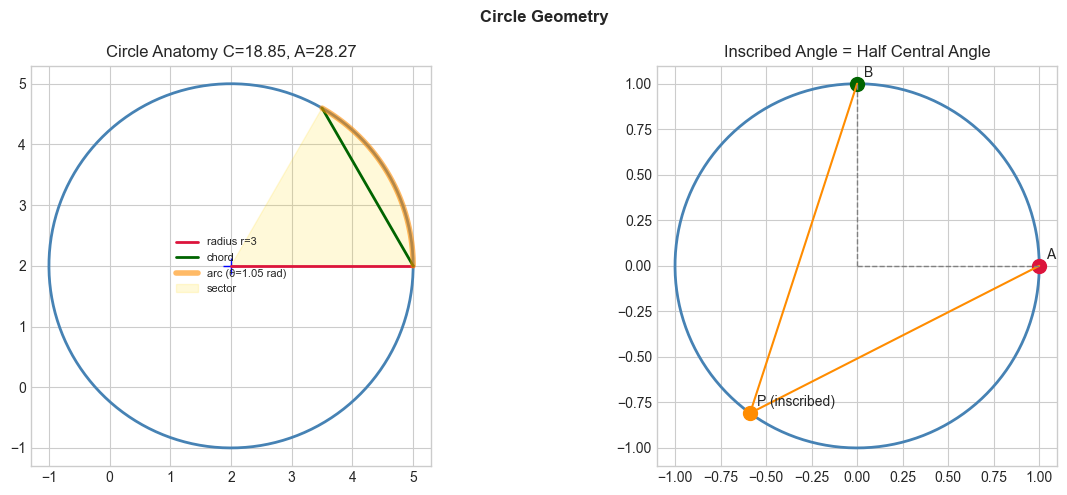

Circle r=3: C=18.8496, A=28.2743
Arc θ=π/3: length=3.1416, sector area=4.7124
Chord θ=π/3: 3.0000


In [2]:
# --- Circle operations and properties ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def circle_arc(cx, cy, r, theta_start, theta_end, n=100):
    """Points on circle arc from theta_start to theta_end (radians)."""
    theta = np.linspace(theta_start, theta_end, n)
    return cx + r*np.cos(theta), cy + r*np.sin(theta)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Circle anatomy
cx, cy, r = 2, 2, 3
theta = np.linspace(0, 2*np.pi, 300)
axes[0].plot(cx+r*np.cos(theta), cy+r*np.sin(theta), 'steelblue', linewidth=2)
axes[0].plot(cx, cy, 'b+', markersize=12)
# Radius
axes[0].plot([cx, cx+r], [cy, cy], 'crimson', linewidth=2, label=f'radius r={r}')
# Chord
theta_chord = np.pi/3
axes[0].plot([cx+r*np.cos(0), cx+r*np.cos(theta_chord)],
             [cy+r*np.sin(0), cy+r*np.sin(theta_chord)], 'darkgreen', linewidth=2, label='chord')
# Arc
arc_x, arc_y = circle_arc(cx, cy, r, 0, theta_chord, 50)
axes[0].plot(arc_x, arc_y, 'darkorange', linewidth=4, alpha=0.6, label=f'arc (θ={theta_chord:.2f} rad)')
# Sector fill
sector_theta = np.linspace(0, theta_chord, 50)
sx = np.append([cx], cx + r*np.cos(sector_theta)); sx = np.append(sx, cx)
sy = np.append([cy], cy + r*np.sin(sector_theta)); sy = np.append(sy, cy)
axes[0].fill(sx, sy, alpha=0.15, color='gold', label='sector')
axes[0].set_aspect('equal'); axes[0].legend(fontsize=8)
axes[0].set_title(f'Circle Anatomy C={2*np.pi*r:.2f}, A={np.pi*r**2:.2f}')

# Inscribed angles
axes[1].plot(np.cos(theta), np.sin(theta), 'steelblue', linewidth=2, label='Unit circle')
# Inscribed angle theorem: inscribed angle = half central angle
central_theta = np.pi/2
A_pt = np.array([np.cos(0), np.sin(0)])
B_pt = np.array([np.cos(central_theta), np.sin(central_theta)])
# Any point on major arc subtends half the central angle
P_pt = np.array([np.cos(np.pi*1.3), np.sin(np.pi*1.3)])
for pt, col, lbl in [(A_pt,'crimson','A'),(B_pt,'darkgreen','B'),(P_pt,'darkorange','P (inscribed)')]:
    axes[1].plot(*pt,'o',color=col,markersize=10)
    axes[1].annotate(lbl, pt, xytext=(5,5), textcoords='offset points', fontsize=10)
axes[1].plot([P_pt[0],A_pt[0]],[P_pt[1],A_pt[1]],'darkorange',lw=1.5)
axes[1].plot([P_pt[0],B_pt[0]],[P_pt[1],B_pt[1]],'darkorange',lw=1.5)
axes[1].plot([0,A_pt[0]],[0,A_pt[1]],'gray',lw=1,linestyle='--')
axes[1].plot([0,B_pt[0]],[0,B_pt[1]],'gray',lw=1,linestyle='--')
axes[1].set_aspect('equal'); axes[1].set_title('Inscribed Angle = Half Central Angle')

plt.suptitle('Circle Geometry', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

r = 3
print(f"Circle r={r}: C={2*np.pi*r:.4f}, A={np.pi*r**2:.4f}")
theta_arc = np.pi/3
print(f"Arc θ=π/3: length={r*theta_arc:.4f}, sector area={r**2*theta_arc/2:.4f}")
print(f"Chord θ=π/3: {2*r*np.sin(theta_arc/2):.4f}")

## Collision Detection

Two circles (c₁, r₁) and (c₂, r₂) collide if d(c₁, c₂) < r₁ + r₂.
A point P is inside circle (c, r) if d(P, c) < r.
These are O(1) tests — used millions of times per second in games.

*(Connects to ch118 — Geometry in Game Development.)*

## Exercises

**Easy 1.** A circle has center (3,4) and passes through (0,0). What is its radius?
**Easy 2.** Compute the arc length and sector area for a circle of r=5 with central angle 2π/3.
**Medium 1.** Implement `circle_circle_intersection(c1,r1,c2,r2)` that returns 0, 1, or 2 intersection points.
**Hard.** Apollonius' problem: given three mutually tangent circles, find the circle tangent to all three. Implement numerically.

## Summary

- Circle: (x-h)²+(y-k)²=r² — the set of points at distance r from center
- Arc = rθ; sector area = r²θ/2; chord = 2r·sin(θ/2)
- Collision detection: compare distance between centers to sum of radii

**Forward:** ch101–103 (Trigonometry) explains where arc and chord formulas come from.